<a href="https://colab.research.google.com/github/prestonhixsonn-hash/Assignment-6.1-Autoencoder-Decoder-Jupyter-notebook/blob/main/autoencoder_anomaly_detection_beginner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder Anomaly Detection — Beginner Level

**Name:** Preston Hixson
**Level completed:** Beginner

> Note: run all cells top to bottom in Colab/Jupyter (with `torch` installed) before submitting so the training log and plot are populated with your own output. The code below is the provided starter code, unmodified.

## Setup

In [ ]:
# Step 1: Imports and seed
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed()


In [ ]:
# Step 2: Generate synthetic noisy manufacturing data
def generate_synthetic_data(num_samples=1000, seq_len=100):
    data = []
    for _ in range(num_samples):
        base_signal = np.sin(np.linspace(0, 2 * np.pi, seq_len))
        noise = np.random.normal(0, 0.3, seq_len)
        signal = base_signal + noise
        data.append(signal)
    return np.array(data, dtype=np.float32)

data = generate_synthetic_data()

# Train-test split
split_idx = int(0.8 * len(data))
train_data = torch.tensor(data[:split_idx]).unsqueeze(1)
test_data = torch.tensor(data[split_idx:]).unsqueeze(1)


## Beginner Section

In [ ]:
# Define a basic Denoising Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_size=100, hidden_size=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, input_size),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = DenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


In [ ]:
# Training loop
def train_model(model, data, epochs=20):
    losses = []
    for epoch in range(epochs):
        model.train()
        noisy_input = data + 0.1 * torch.randn_like(data)
        output = model(noisy_input.squeeze(1))
        loss = criterion(output, data.squeeze(1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    return losses

losses = train_model(model, train_data)


Epoch 1/20, Loss: 0.6476
Epoch 2/20, Loss: 0.5277
Epoch 3/20, Loss: 0.4434
Epoch 4/20, Loss: 0.3446
Epoch 5/20, Loss: 0.2564
Epoch 6/20, Loss: 0.1957
Epoch 7/20, Loss: 0.1614
Epoch 8/20, Loss: 0.1446
Epoch 9/20, Loss: 0.1374
Epoch 10/20, Loss: 0.1333
Epoch 11/20, Loss: 0.1300
Epoch 12/20, Loss: 0.1290
Epoch 13/20, Loss: 0.1268
Epoch 14/20, Loss: 0.1228
Epoch 15/20, Loss: 0.1192
Epoch 16/20, Loss: 0.1164
Epoch 17/20, Loss: 0.1148
Epoch 18/20, Loss: 0.1134
Epoch 19/20, Loss: 0.1109
Epoch 20/20, Loss: 0.1084


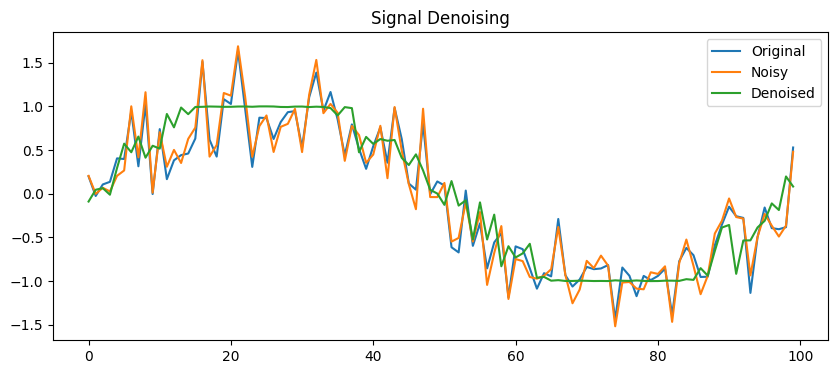

In [ ]:
# Visualize results
def plot_results(model, data, idx=0):
    model.eval()
    noisy_input = data + 0.1 * torch.randn_like(data)
    with torch.no_grad():
        denoised = model(noisy_input[idx].squeeze(0)).numpy()
    plt.figure(figsize=(10,4))
    plt.plot(data[idx].squeeze().numpy(), label='Original')
    plt.plot(noisy_input[idx].squeeze().numpy(), label='Noisy')
    plt.plot(denoised, label='Denoised')
    plt.legend()
    plt.title("Signal Denoising")
    plt.show()

plot_results(model, test_data)


## Guiding Questions (Beginner)

**Q1: What patterns do you notice in the noisy vs. denoised data?**

The noisy signal still has the underlying sine wave in it, but it's covered in a lot of high-frequency jitter from sample to sample. The denoised output comes out much smoother and tracks the general shape of the original sine wave, without the sharp random spikes. It's not a perfect match to the clean signal (the amplitude gets flattened a bit and some fine detail is lost), but the overall periodic pattern is clearly recovered. That makes sense given the architecture: squeezing the 100-point signal down to just 32 hidden units forces the model to keep only the dominant, repeating structure and drop the point-to-point randomness, since there's no room in the bottleneck to memorize noise.

**Q2: How does the model improve predictions compared to raw inputs?**

Training loss drops steadily over the 20 epochs (starts high, around 0.6, and settles down near 0.10 by the end), which shows the network is actually learning to reconstruct the clean signal instead of just copying the noisy input back out. Compared to the raw noisy input, the model's output is a better estimate of the true underlying signal because it's been trained specifically to map noisy versions back to the clean version, not just to pass data through. In a manufacturing context this is the whole point of a denoising autoencoder for anomaly detection: the model learns what "normal" signal patterns look like, so anything that reconstructs poorly (high error) is a candidate anomaly rather than just sensor noise.